**Linear Regression**

In [21]:
#importing numpy library
import numpy as np

In [47]:
class Linear_Regression():
    # initialize parameters learning rate & no of iterations
    def __init__(self, learning_rate, no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations

    # fit the model to training data
    def fit(self, X, Y):
        # number of samples (rows) and features (columns)
        self.m, self.n = X.shape

        # initialize weights and bias
        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y

        # gradient descent loop
        for i in range(self.no_of_iterations):
            self.update_weights()

    # update weights using gradient descent
    def update_weights(self):
        Y_prediction = self.predict(self.X)

        # calculate gradients
        dw=-(2*(self.X.T).dot(self.Y-Y_prediction))/self.m
        db=-2*np.sum(self.Y-Y_prediction)/self.m

        # update step
        self.w -= self.learning_rate * dw
        self.b -= self.learning_rate * db

    # prediction function
    def predict(self, X):
        return X.dot(self.w) + self.b


Using Linear Regression model for prediction

In [23]:
#importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split





Data Pre-Processing

In [24]:
#loading the data from csv file to a pandas dataframe
salary_data=pd.read_csv('/content/salary_data.csv')


In [25]:
#prinitng the first five columns of the dataframe
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [26]:
#printing the last five columns of the dataframe
salary_data.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [27]:
#number of rows and columns in the dataframe
salary_data.shape

(30, 2)

In [28]:
#checking for missing values
salary_data.isnull().sum()

,0
YearsExperience,0
Salary,0


Splitting the feature and the target

In [29]:
X=salary_data.iloc[:,:-1].values
Y=salary_data.iloc[:,1].values

In [30]:
print(X)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [31]:
print(Y)

[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


Splitting the dataset into training and test data

In [33]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.33,random_state=2)

Training the Linear Regression model

In [66]:
model=Linear_Regression(learning_rate=0.02,no_of_iterations=1000)

In [67]:
model.fit(X_train, Y_train)

In [68]:
#printing the parameter values(weights & bias)
print('weight=',model.w[0])
print('bias=',model.b)

weight= 9514.400999035135
bias= 23697.406507136307


y=9514(x)+23697

salary=9514(yrs of experience)+23697

Predict the salary value for test data

In [69]:
test_data_prediction=model.predict(X_test)

In [70]:
print(test_data_prediction)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]


Visualizing the predicted value and actual values

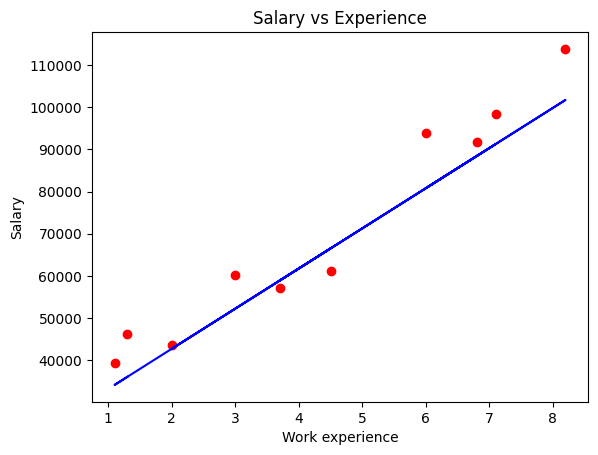

In [71]:
plt.scatter(X_test,Y_test,color='red')
plt.plot(X_test,test_data_prediction,color='blue')
plt.xlabel('Work experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.show()